In [0]:
from pyspark.sql.functions import *
import pandas as pd
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [0]:
from pyspark.sql.functions import col 
appointments_data = [ (1001, "Hyderabad", "Cardiology", "Apollo", 1500, "Completed"), (1002, "Bangalore", "Neurology", "Yashoda", 2200, "Completed"), (1003, "Mumbai", "Dermatology", "Care", 900, "Pending"), (1004, "Delhi", "Orthopedics", "Max", 2500, "Completed"), (1005, "Chennai", "Pediatrics", "Apollo", 1200, "Cancelled"), (1006, "Hyderabad", "Cardiology", "Care", 3000, "Completed"), (1007, "Bangalore", "Dermatology", "Apollo", 1000, "Completed"), (1008, "Mumbai", "Neurology", "Max", 2600, "Pending"), (1009, "Delhi", "Cardiology", "Yashoda", 2800, "Completed"), (1010, "Chennai", "Orthopedics", "Care", 2400, "Completed"), (1011, "Hyderabad", "Pediatrics", "Apollo", 1100, "Completed"), (1012, "Bangalore", "Cardiology", "Max", 3200, "Completed"), (1013, "Mumbai", "Pediatrics", "Yashoda", 1300, "Cancelled"), (1014, "Delhi", "Neurology", "Apollo", 2700, "Completed"), (1015, "Chennai", "Dermatology", "Care", 950, "Pending") ] 
columns = [ "appointment_id", "city", "department", "hospital", "consultation_fee", "status" ] 
df = spark.createDataFrame(appointments_data, columns) 
display(df)

appointment_id,city,department,hospital,consultation_fee,status
1001,Hyderabad,Cardiology,Apollo,1500,Completed
1002,Bangalore,Neurology,Yashoda,2200,Completed
1003,Mumbai,Dermatology,Care,900,Pending
1004,Delhi,Orthopedics,Max,2500,Completed
1005,Chennai,Pediatrics,Apollo,1200,Cancelled
1006,Hyderabad,Cardiology,Care,3000,Completed
1007,Bangalore,Dermatology,Apollo,1000,Completed
1008,Mumbai,Neurology,Max,2600,Pending
1009,Delhi,Cardiology,Yashoda,2800,Completed
1010,Chennai,Orthopedics,Care,2400,Completed


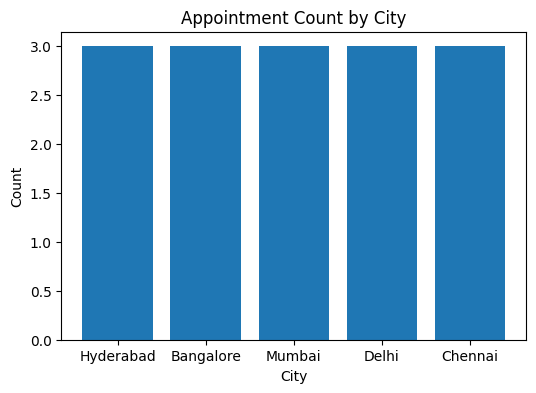

In [0]:
city_df = df.groupBy("city").count().toPandas()

plt.figure(figsize=(6,4))
plt.bar(city_df["city"], city_df["count"])
plt.title("Appointment Count by City")
plt.xlabel("City")
plt.ylabel("Count")
plt.show()

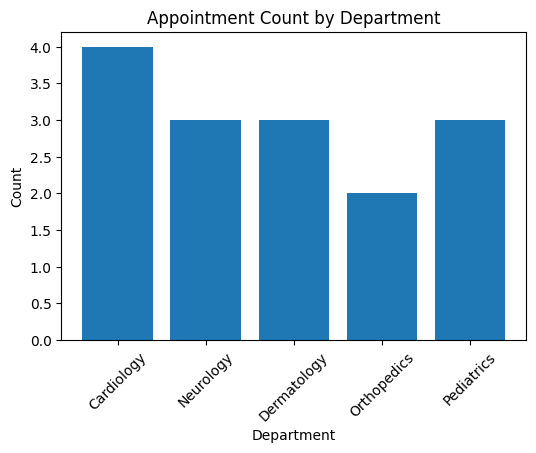

In [0]:
dept_df = df.groupBy("department").count().toPandas()

plt.figure(figsize=(6,4))
plt.bar(dept_df["department"], dept_df["count"])
plt.title("Appointment Count by Department")
plt.xlabel("Department")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

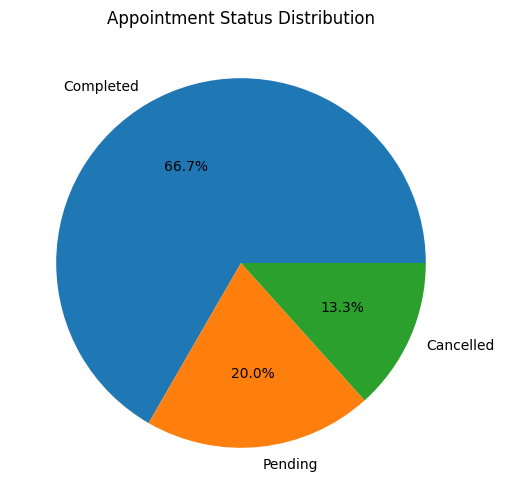

In [0]:
status_df = df.groupBy("status").count().toPandas()

plt.figure(figsize=(6,6))
plt.pie(status_df["count"], labels=status_df["status"], autopct="%1.1f%%")
plt.title("Appointment Status Distribution")
plt.show()

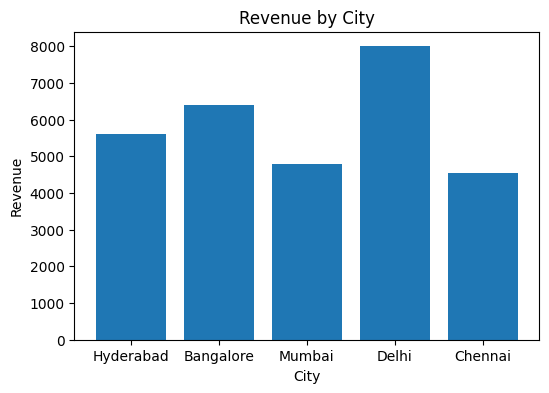

In [0]:
city_rev = df.groupBy("city").agg(
    sum("consultation_fee").alias("revenue")
).toPandas()

plt.figure(figsize=(6,4))
plt.bar(city_rev["city"], city_rev["revenue"])
plt.title("Revenue by City")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.show()

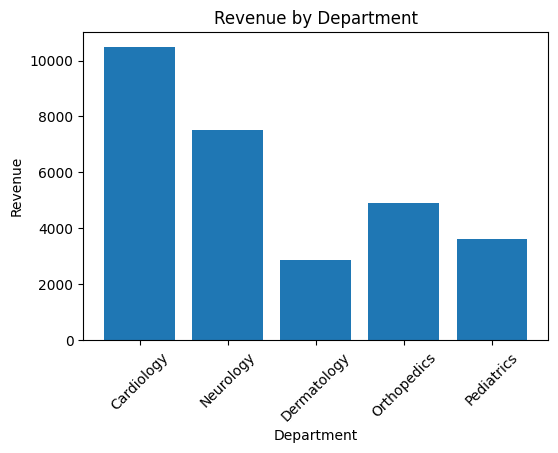

In [0]:
dept_rev = df.groupBy("department").agg(
    sum("consultation_fee").alias("revenue")
).toPandas()

plt.figure(figsize=(6,4))
plt.bar(dept_rev["department"], dept_rev["revenue"])
plt.title("Revenue by Department")
plt.xlabel("Department")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

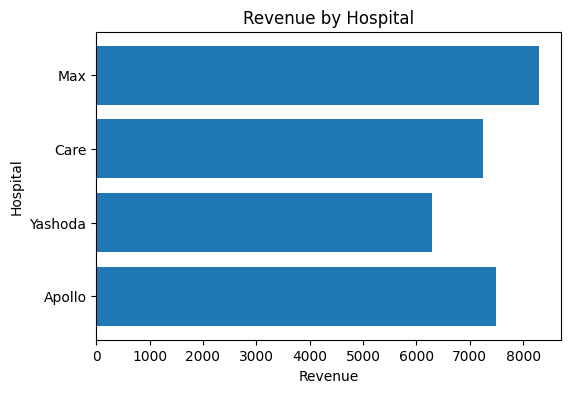

In [0]:
hospital_rev = df.groupBy("hospital").agg(
    sum("consultation_fee").alias("revenue")
).toPandas()

plt.figure(figsize=(6,4))
plt.barh(hospital_rev["hospital"], hospital_rev["revenue"])
plt.title("Revenue by Hospital")
plt.xlabel("Revenue")
plt.ylabel("Hospital")
plt.show()

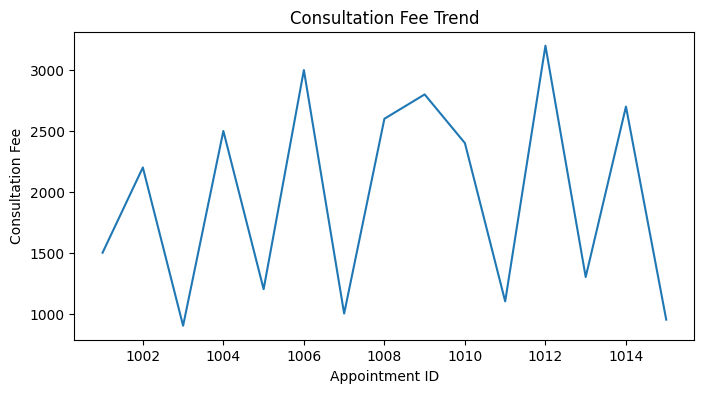

In [0]:
line_df = df.orderBy("appointment_id").toPandas()

plt.figure(figsize=(8,4))
plt.plot(line_df["appointment_id"], line_df["consultation_fee"])
plt.title("Consultation Fee Trend")
plt.xlabel("Appointment ID")
plt.ylabel("Consultation Fee")
plt.show()

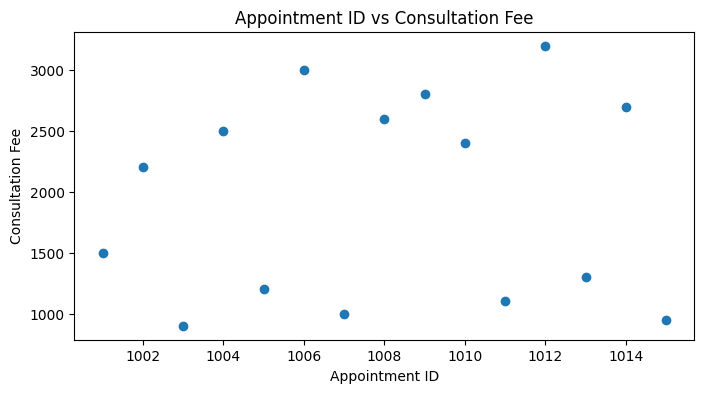

In [0]:
scatter_df = df.toPandas()

plt.figure(figsize=(8,4))
plt.scatter(
    scatter_df["appointment_id"],
    scatter_df["consultation_fee"]
)
plt.title("Appointment ID vs Consultation Fee")
plt.xlabel("Appointment ID")
plt.ylabel("Consultation Fee")
plt.show()

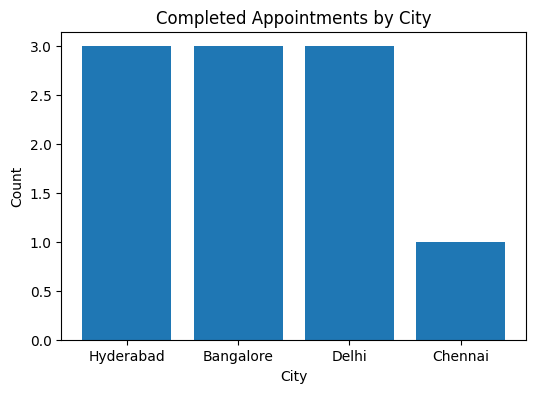

In [0]:
completed_df = df.filter(
    col("status") == "Completed"
)

result = completed_df.groupBy("city").count().toPandas()

plt.figure(figsize=(6,4))
plt.bar(result["city"], result["count"])
plt.title("Completed Appointments by City")
plt.xlabel("City")
plt.ylabel("Count")
plt.show()

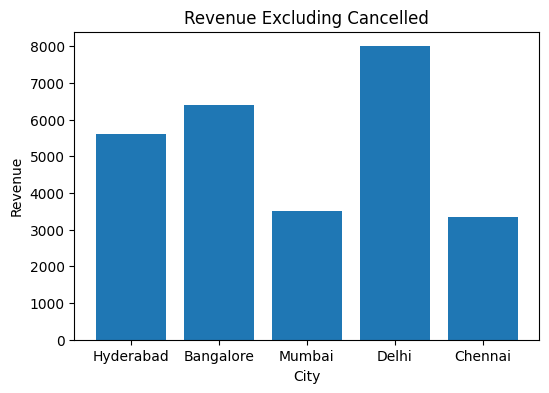

In [0]:
active_df = df.filter(
    col("status") != "Cancelled"
)

result = active_df.groupBy("city").agg(
    sum("consultation_fee").alias("revenue")
).toPandas()

plt.figure(figsize=(6,4))
plt.bar(result["city"], result["revenue"])
plt.title("Revenue Excluding Cancelled")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.show()

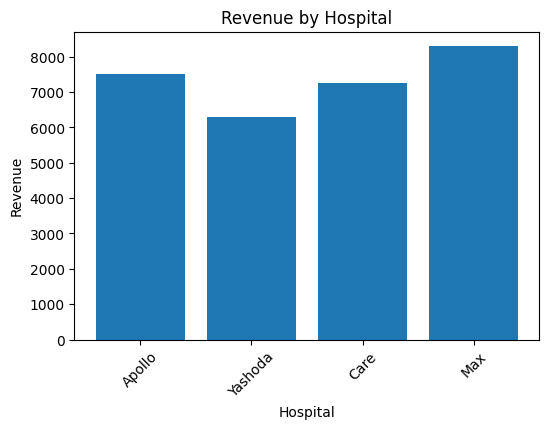

In [0]:
hospital_rev = df.groupBy("hospital").agg(
    sum("consultation_fee").alias("revenue")
).toPandas()

plt.figure(figsize=(6,4))
plt.bar(hospital_rev["hospital"], hospital_rev["revenue"])
plt.xticks(rotation=45)
plt.title("Revenue by Hospital")
plt.xlabel("Hospital")
plt.ylabel("Revenue")
plt.show()

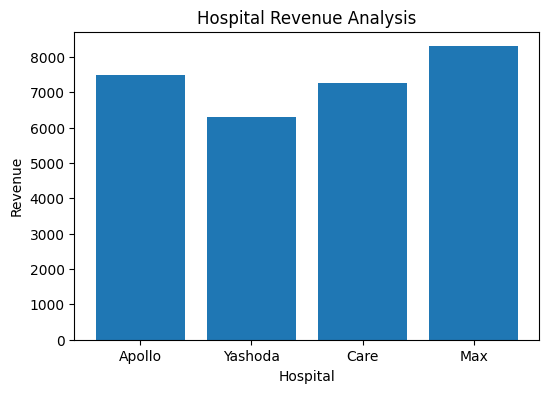

In [0]:
hospital_rev = df.groupBy("hospital").agg(
    sum("consultation_fee").alias("revenue")
).toPandas()

plt.figure(figsize=(6,4))
plt.bar(hospital_rev["hospital"], hospital_rev["revenue"])
plt.title("Hospital Revenue Analysis")
plt.xlabel("Hospital")
plt.ylabel("Revenue")
plt.show()

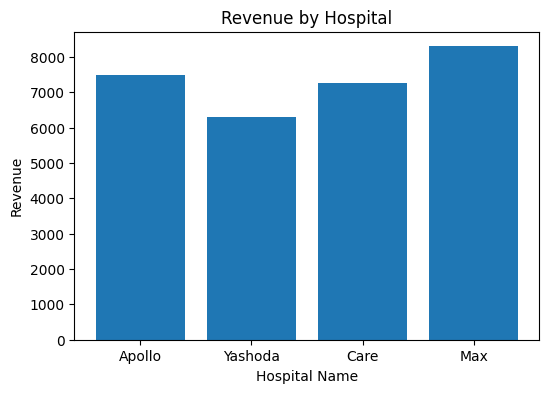

In [0]:
hospital_rev = df.groupBy("hospital").agg(
    sum("consultation_fee").alias("revenue")
).toPandas()

plt.figure(figsize=(6,4))
plt.bar(hospital_rev["hospital"], hospital_rev["revenue"])
plt.title("Revenue by Hospital")
plt.xlabel("Hospital Name")
plt.ylabel("Revenue")
plt.show()

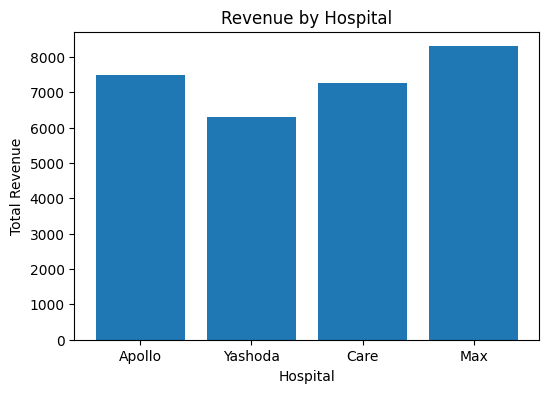

In [0]:
hospital_rev = df.groupBy("hospital").agg(
    sum("consultation_fee").alias("revenue")
).toPandas()

plt.figure(figsize=(6,4))
plt.bar(hospital_rev["hospital"], hospital_rev["revenue"])
plt.title("Revenue by Hospital")
plt.xlabel("Hospital")
plt.ylabel("Total Revenue")
plt.show()

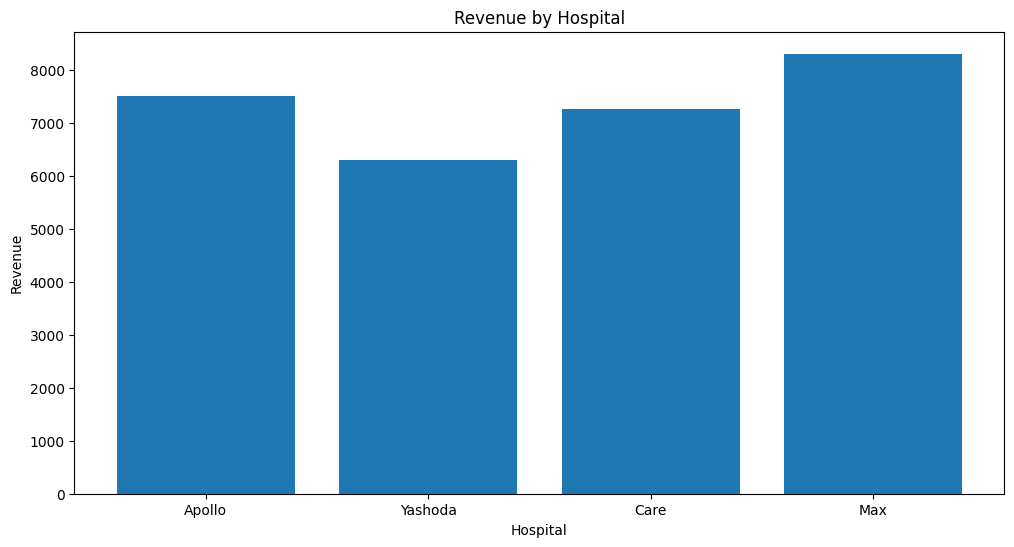

In [0]:
hospital_rev = df.groupBy("hospital").agg(
    sum("consultation_fee").alias("revenue")
).toPandas()

plt.figure(figsize=(12,6))
plt.bar(hospital_rev["hospital"], hospital_rev["revenue"])
plt.title("Revenue by Hospital")
plt.xlabel("Hospital")
plt.ylabel("Revenue")
plt.show()

In [0]:
top_city = df.groupBy("city").agg(
    sum("consultation_fee").alias("revenue")
).orderBy(
    col("revenue").desc()
)

display(top_city.limit(3))

city,revenue
Delhi,8000
Bangalore,6400
Hyderabad,5600


In [0]:
top_dept = df.groupBy("department").agg(
    sum("consultation_fee").alias("revenue")
).orderBy(
    col("revenue").desc()
)

display(top_dept.limit(3))

department,revenue
Cardiology,10500
Neurology,7500
Orthopedics,4900


In [0]:
low_hospital = df.groupBy("hospital").agg(
    sum("consultation_fee").alias("revenue")
).orderBy("revenue")

display(low_hospital.limit(1))

hospital,revenue
Yashoda,6300


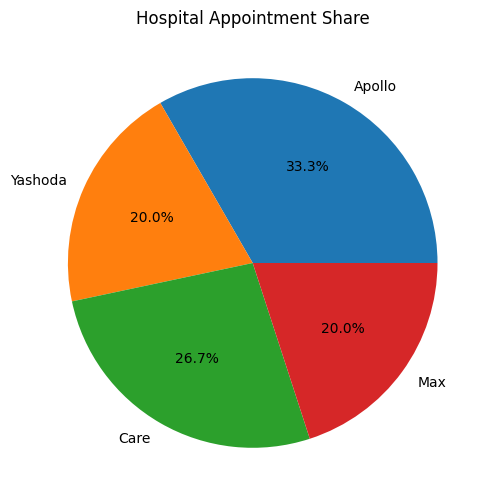

In [0]:
hospital_count = df.groupBy("hospital").count().toPandas()

plt.figure(figsize=(6,6))
plt.pie(
    hospital_count["count"],
    labels=hospital_count["hospital"],
    autopct="%1.1f%%"
)
plt.title("Hospital Appointment Share")
plt.show()

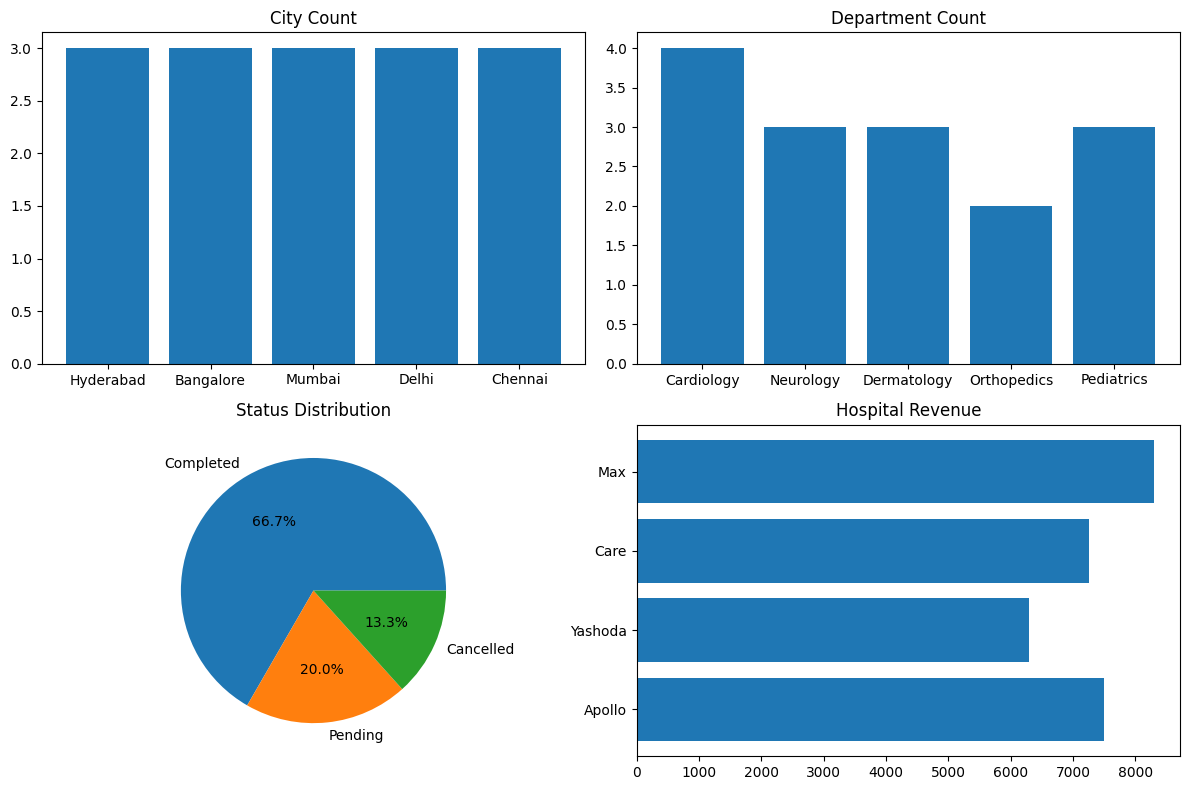

In [0]:
fig, ax = plt.subplots(2,2,figsize=(12,8))

city_df = df.groupBy("city").count().toPandas()
dept_df = df.groupBy("department").count().toPandas()
status_df = df.groupBy("status").count().toPandas()
hospital_rev = df.groupBy("hospital").agg(
    sum("consultation_fee").alias("revenue")
).toPandas()

ax[0,0].bar(city_df["city"], city_df["count"])
ax[0,0].set_title("City Count")

ax[0,1].bar(dept_df["department"], dept_df["count"])
ax[0,1].set_title("Department Count")

ax[1,0].pie(
    status_df["count"],
    labels=status_df["status"],
    autopct="%1.1f%%"
)
ax[1,0].set_title("Status Distribution")

ax[1,1].barh(
    hospital_rev["hospital"],
    hospital_rev["revenue"]
)
ax[1,1].set_title("Hospital Revenue")

plt.tight_layout()
plt.show()